# QTL annotations

In [7]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### SpliceAI

In [55]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path)
vep_df["is_ref"] = vep_df["sample"] == "REF"
vep_df.head()

,variant_idx,chromosome,position,ref_allele,alt_allele,sample_id,hap_id,flag,max_delta_score,max_delta_coord,max_delta_score_type,max_delta_strand,pos_acceptor_gain_max,pos_acceptor_gain_max_coord,pos_acceptor_loss_max,pos_acceptor_loss_max_coord,pos_donor_gain_max,pos_donor_gain_max_coord,pos_donor_loss_max,pos_donor_loss_max_coord,neg_acceptor_gain_max,neg_acceptor_gain_max_coord,neg_acceptor_loss_max,neg_acceptor_loss_max_coord,neg_donor_gain_max,neg_donor_gain_max_coord,neg_donor_loss_max,neg_donor_loss_max_coord,sample,Population,Super Population,chr,pos,clinvar_id,ref,alt,3ss_can,3ss_eprox,3ss_iprox,bp_region,5ss_can,5ss_eprox,5ss_iprox,exon_core,svdb_id,hgvs,method,spliceogenicity,gene,GENEINFO,CLNSIG,CLNREVSTAT,CLNSIG_simplified,site,VEP,is_ref
0,0,chr10,236835,T,C,0,0,0,0.065125,236840,acceptor_loss,pos,0.004395,236838,0.065125,236840,0.000002,236841,0.000078,236840,0.000016,236883,4.172325e-07,236833,0.013672,236883,1.788139e-07,236873,HG00096,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065125,False
1,0,chr10,236835,T,C,0,1,0,0.067566,236840,acceptor_loss,pos,0.003906,236838,0.067566,236840,0.000001,236841,0.000080,236840,0.000016,236883,4.172325e-07,236833,0.013794,236883,1.192093e-07,236873,HG00096,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.067566,False
2,0,chr10,236835,T,C,1,0,0,0.065735,236840,acceptor_loss,pos,0.004395,236838,0.065735,236840,0.000001,236841,0.000077,236840,0.000017,236883,4.172325e-07,236833,0.013184,236883,1.192093e-07,236873,HG00097,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065735,False
3,0,chr10,236835,T,C,1,1,0,0.065491,236840,acceptor_loss,pos,0.004395,236838,0.065491,236840,0.000001,236841,0.000079,236840,0.000017,236883,4.172325e-07,236833,0.013916,236883,1.788139e-07,236873,HG00097,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065491,False
4,0,chr10,236835,T,C,2,0,0,0.065430,236840,acceptor_loss,pos,0.004395,236838,0.065430,236840,0.000001,236841,0.000078,236840,0.000016,236883,4.172325e-07,236833,0.013306,236883,1.192093e-07,236873,HG00099,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065430,False


### All others (Flashzoi)

In [131]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)
vep_df["is_ref"] = vep_df["sample"] == "REF"

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.csv.gz")

## Import QTL data

QTL data source: https://www.finucanelab.org/data

In [ ]:
import gzip
import re

files = glob.glob(os.path.expanduser("~/projects/data/QTL/EMS_public/*.tsv.bgz"))

r2_df = []
for file in tqdm(files, desc="Processing tissues"):
    tissue = re.search(r'ems_top_(.+?)\.tsv\.bgz$', os.path.basename(file)).group(1)
    ems = pd.read_csv(gzip.open(file, "rt"), sep="\t")
    
    # Add variant name
    ems['chrom'] = ems['v'].str.split('_').str[0]
    ems['chromStart'] = ems['v'].str.split('_').str[1].astype(int) 
    ems['REF'] = ems['v'].str.split('_').str[2]
    ems['ALT'] = ems['v'].str.split('_').str[3]
    ems = utils.add_variant_name(ems,
                                chrom_col='chrom',
                                start_col='chromStart',
                                end_col=None,
                                ref_col='REF',
                                alt_col='ALT',
                                alias='site',
                                force=False)

    # Aggregate VEP scores
    agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified"] if x in vep_df.columns]
    vep_agg = vep_df.groupby(agg_cols, observed=True)["VEP"].mean().reset_index()

    # Merge VEP and EMS
    vep_agg["site"] = vep_agg["site"].astype(object)
    ems["site"] = ems["site"].astype(object)
    vep_annot = vep_agg.merge(ems, on="site", how="inner")

    # Check if there are any variants
    if vep_annot.empty:
        print(f"No overlapping variants found for {tissue}")
        continue
    
    # Run correlation analysis
    r2_tmp = ev.run_correlation_analysis(vep_annot, 
                                         ANNOT_COLS=["rf_score_raw","ems","ems_normalized"],
                                         verbose=False)
    r2_tmp["tissue"] = tissue 
    r2_df.append(r2_tmp)

r2_df = pd.concat(r2_df)
r2_df.head() 

Processing tissues:   0%|          | 0/49 [00:00<?, ?it/s]

Processing tissues: 100%|██████████| 49/49 [03:02<00:00,  3.73s/it]


,annotation,ref_r,nonref_r,r_diff,ref_n,nonref_n,ref_p,nonref_p,tissue
0,rf_score_raw,0.138234,0.147043,0.008808,309,309,0.015025,0.009643,Lung
1,ems,0.160686,0.168205,0.007519,309,309,0.004632,0.003017,Lung
2,ems_normalized,0.160686,0.168205,0.007519,309,309,0.004632,0.003017,Lung
0,rf_score_raw,0.179189,0.025381,-0.153808,173,173,0.018329,0.740295,Ovary
1,ems,0.050825,0.029931,-0.020893,173,173,0.506642,0.695856,Ovary


In [146]:
r2_df["tissue_annotation"] = r2_df["tissue"] + " (" + r2_df["annotation"] + ")"
r2_df.sort_values("r_diff", ascending=False, inplace=True)

<string>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


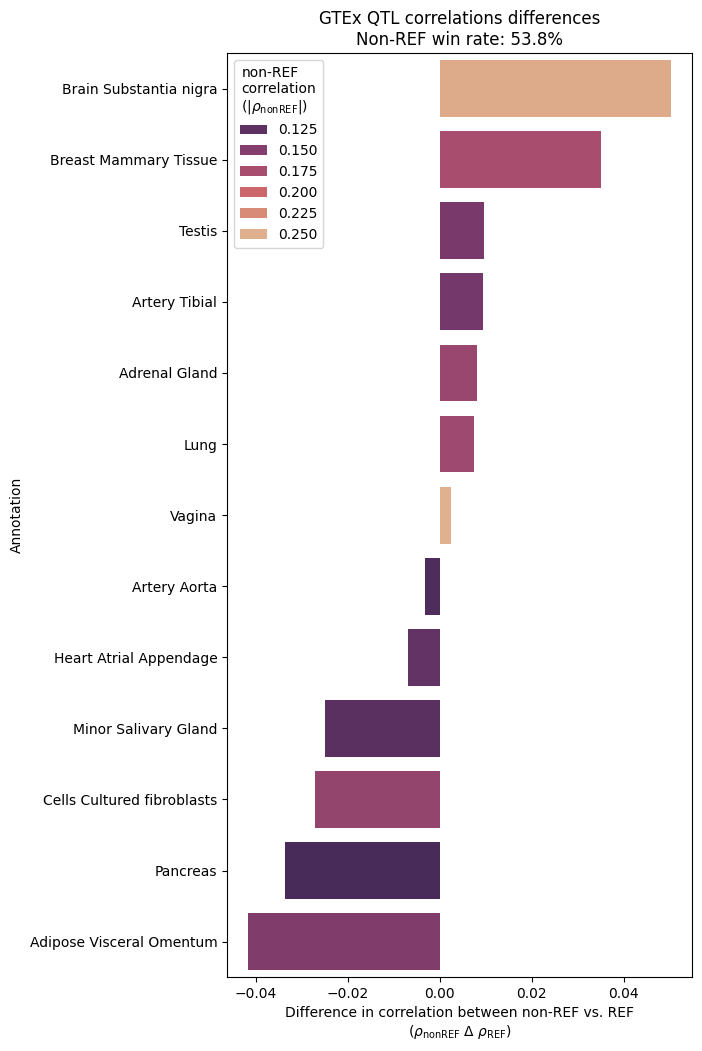

In [ ]:
min_n = 0
max_p = 0.05
r2_filt = ev.plot_correlation_analysis(r2_df, 
                             min_n=0,
                             max_p=0.05,
                             annotations=["ems_normalized"],
                             figsize=(6, 12),
                             hue="nonref_r_abs", 
                             y_var="tissue",
                             title="GTEx QTL correlation differences")

In [169]:
(r2_filt["r_diff"]>0).sum() / len(r2_filt)

0.5384615384615384

In [170]:
r2_filt.groupby(["annotation"])["r_diff"].mean()

annotation
ems_normalized   -0.001172
Name: r_diff, dtype: float64